### Initial

In [10]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
words = open('../words.txt', 'r').read().splitlines()
words[:8]

['abakus',
 'abandon',
 'abazja',
 'abażur',
 'abażurek',
 'abdukcja',
 'abduktor',
 'abdykacja']

In [12]:
len(words)

48178

In [13]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'w', 23: 'y', 24: 'z', 25: 'ó', 26: 'ą', 27: 'ć', 28: 'ę', 29: 'ł', 30: 'ń', 31: 'ś', 32: 'ź', 33: 'ż', 0: '.'}


In [14]:
block_size = 3  # context size

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [15]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

torch.Size([400292, 3]) torch.Size([400292])
torch.Size([50134, 3]) torch.Size([50134])
torch.Size([50015, 3]) torch.Size([50015])


In [16]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g)
b1 = torch.rand(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.rand(vocab_size, generator=g)

parameters = [C, W1, b1, W2, b2]
print("number of parameters: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

number of parameters:  13374


In [17]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    emb = C[Xb]                             # chars embedded into vectors
    emb_cat = emb.view(emb.shape[0], -1)    # concatenated vectors
    hpreact = emb_cat @ W1 + b1             # hidden layer pre-activation
    h = torch.tanh(hpreact)                 # hidden layer
    logits = h @ W2 + b2                    # output layer
    loss = F.cross_entropy(logits, Y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 26.6190
  10000/ 200000: 1.9745
  20000/ 200000: 2.0632
  30000/ 200000: 2.1488
  40000/ 200000: 2.1750
  50000/ 200000: 2.1088
  60000/ 200000: 2.2279
  70000/ 200000: 2.1154
  80000/ 200000: 2.2952
  90000/ 200000: 2.2802
 100000/ 200000: 2.0214
 110000/ 200000: 1.6669
 120000/ 200000: 1.9372
 130000/ 200000: 2.7554
 140000/ 200000: 2.1744
 150000/ 200000: 2.3510
 160000/ 200000: 2.3775
 170000/ 200000: 2.2983
 180000/ 200000: 1.8711
 190000/ 200000: 1.9123


In [18]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, Y_train),
        'val': (X_val, Y_val),
        'test': (X_test, Y_test),
    }[split]

    emb = C[x]      # (N, block_size, n_emb)
    embcat = emb.view(emb.shape[0], -1)    # (N, block_size * n_emb)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0468993186950684
val 2.0606400966644287


In [19]:
# sampling
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size

    while True:
        # forward pass
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        #print(C[context].shape)
        #print(C[torch.tensor([context])].shape)
        #print(emb.view(1, -1).shape)

        # sample
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        context = context[1:] + [ix]
        out.append(ix)
        
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))


cyd.
gubożywaca.
momatompleść.
wypadek.
głowanie.
sprężynramboater.
zgryjenieżetenienie.
prawiadziaka.
czułostwo.
peryzm.
odsenka.
sopomatyna.
śliątantar.
uza.
plestarium.
mlużedno.
śs.
zracja.
świec.
kapener.


### better logits initialization

we had a loss=26 and the loss we could expect with better initial logits is:

In [20]:
-torch.tensor(1/34.0).log()

tensor(3.5264)

at first logits are random and take extreme values so the net is confident about wrong results

In [21]:
torch.rand(vocab_size, generator=g) * 0

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [22]:
torch.zeros(vocab_size)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [23]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g)
b1 = torch.rand(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
print("number of parameters: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

number of parameters:  13374


In [24]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    emb = C[Xb]                             # chars embedded into vectors
    emb_cat = emb.view(emb.shape[0], -1)    # concatenated vectors
    hpreact = emb_cat @ W1 + b1             # hidden layer pre-activation
    h = torch.tanh(hpreact)                 # hidden layer
    logits = h @ W2 + b2                    # output layer
    loss = F.cross_entropy(logits, Y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    #break   # to see loss after first epoch

      0/ 300000: 3.8496
  10000/ 300000: 1.7273
  20000/ 300000: 2.0083
  30000/ 300000: 1.9009
  40000/ 300000: 2.0270
  50000/ 300000: 1.8354
  60000/ 300000: 1.8614
  70000/ 300000: 1.8334
  80000/ 300000: 2.3005
  90000/ 300000: 1.7795
 100000/ 300000: 2.0534
 110000/ 300000: 1.9209
 120000/ 300000: 2.2372
 130000/ 300000: 2.2638
 140000/ 300000: 2.1448
 150000/ 300000: 1.6828
 160000/ 300000: 2.2672
 170000/ 300000: 2.5483
 180000/ 300000: 2.3306
 190000/ 300000: 2.3409
 200000/ 300000: 1.7505
 210000/ 300000: 1.9698
 220000/ 300000: 1.6758
 230000/ 300000: 1.6576
 240000/ 300000: 2.2750
 250000/ 300000: 1.7501
 260000/ 300000: 1.5704
 270000/ 300000: 1.8428
 280000/ 300000: 1.8641
 290000/ 300000: 2.1398


In [25]:
split_loss('train')
split_loss('val')

train 2.03019380569458
val 2.060802698135376


why we don't zero w2?

In [26]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g)
b1 = torch.rand(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
print("number of parameters: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

number of parameters:  13374


In [27]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    emb = C[Xb]                             # chars embedded into vectors
    emb_cat = emb.view(emb.shape[0], -1)    # concatenated vectors
    hpreact = emb_cat @ W1 + b1             # hidden layer pre-activation
    h = torch.tanh(hpreact)                 # hidden layer
    logits = h @ W2 + b2                    # output layer
    loss = F.cross_entropy(logits, Y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break   # to see loss after first epoch

      0/ 300000: 3.5264


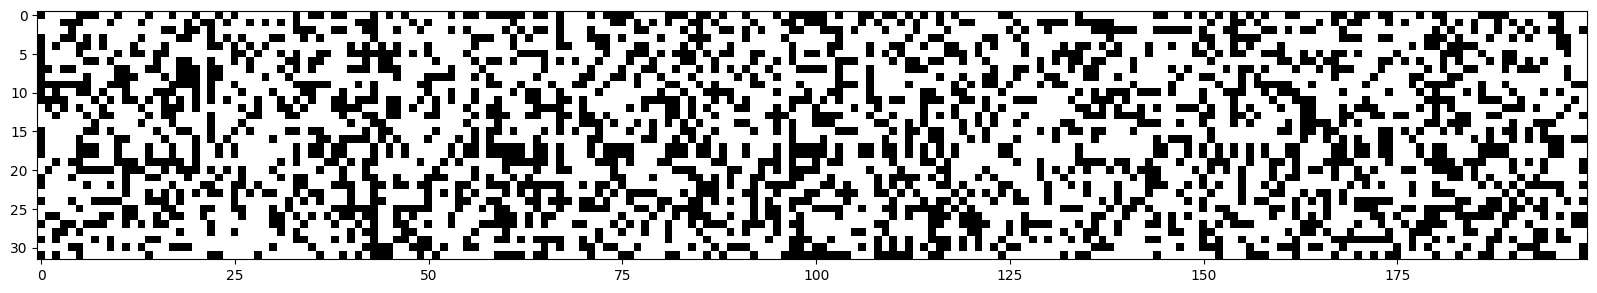

In [28]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest')

if a whole column is white it means dead neurons

(array([2204.,  156.,   86.,   61.,   59.,   36.,   40.,   30.,   32.,
          21.,   26.,   24.,   20.,   29.,   22.,   25.,   14.,   21.,
          19.,   23.,   22.,   20.,   12.,   22.,   19.,   18.,   17.,
          16.,   16.,   20.,   29.,   23.,   22.,   26.,   17.,   26.,
          17.,   28.,   17.,   22.,   34.,   23.,   27.,   41.,   42.,
          52.,   68.,  107.,  165., 2484.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

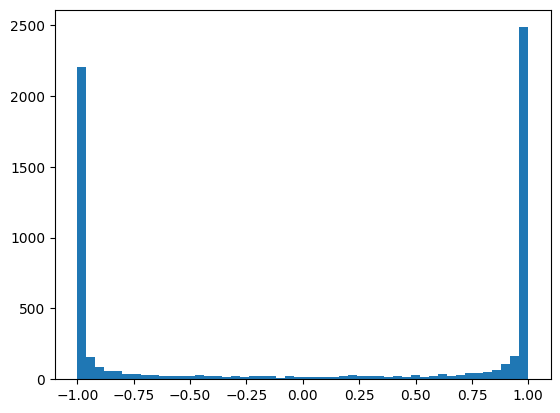

In [29]:
plt.hist(h.view(-1).tolist(), 50)

(array([  1.,   0.,   2.,   2.,   5.,   4.,   6.,   8.,  13.,  15.,  23.,
         40.,  41.,  73.,  87., 131., 148., 193., 181., 224., 282., 303.,
        359., 344., 365., 397., 349., 413., 351., 338., 294., 263., 229.,
        209., 170., 120., 100.,  81.,  63.,  52.,  40.,  29.,  27.,   8.,
          5.,   7.,   3.,   1.,   0.,   1.]),
 array([-21.43814468, -20.59739315, -19.75664162, -18.91589008,
        -18.07513855, -17.23438702, -16.39363548, -15.55288395,
        -14.71213242, -13.87138088, -13.03062935, -12.18987782,
        -11.34912628, -10.50837475,  -9.66762321,  -8.82687168,
         -7.98612015,  -7.14536861,  -6.30461708,  -5.46386555,
         -4.62311401,  -3.78236248,  -2.94161095,  -2.10085941,
         -1.26010788,  -0.41935635,   0.42139519,   1.26214672,
          2.10289825,   2.94364979,   3.78440132,   4.62515285,
          5.46590439,   6.30665592,   7.14740746,   7.98815899,
          8.82891052,   9.66966206,  10.51041359,  11.35116512,
         12.191916

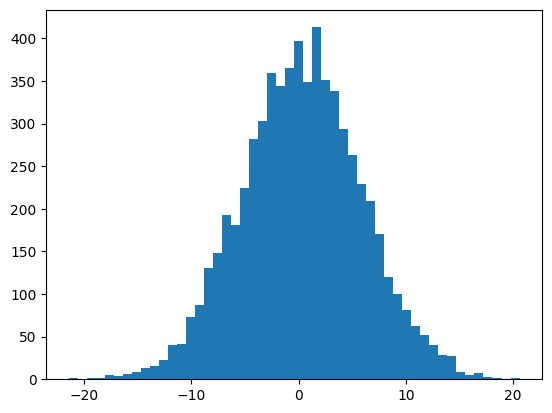

In [30]:
plt.hist(hpreact.view(-1).tolist(), 50)

a lot of values in tanh input are -1 or 1, this means that the net is not really learning, because when we backprop tanh we do `self.grad += (1 - t**2) * out.grad` and t**2 is 1, so the gradient doesn't change

in our case it's not a problem but generally this is not good

In [31]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * 0.2
b1 = torch.rand(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
print("number of parameters: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

number of parameters:  13374


In [32]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    emb = C[Xb]                             # chars embedded into vectors
    emb_cat = emb.view(emb.shape[0], -1)    # concatenated vectors
    hpreact = emb_cat @ W1 + b1             # hidden layer pre-activation
    h = torch.tanh(hpreact)                 # hidden layer
    logits = h @ W2 + b2                    # output layer
    loss = F.cross_entropy(logits, Y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break   # to see loss after first epoch

      0/ 300000: 3.5004


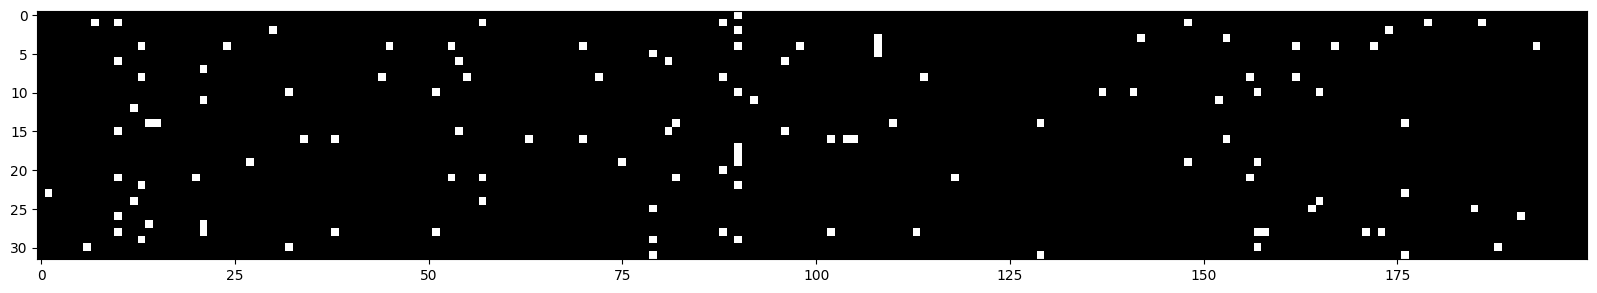

In [33]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest')

(array([286., 258., 222., 171., 134., 144., 160., 129., 138., 120., 131.,
        113., 105., 111., 104.,  96.,  94.,  82., 104.,  81.,  93., 105.,
        102.,  92.,  68.,  99.,  85.,  91.,  95.,  93.,  89., 102.,  89.,
        135., 103.,  88., 101., 102., 129., 138., 118., 101., 109., 135.,
        157., 153., 186., 187., 203., 269.]),
 array([-9.99659121e-01, -9.59679909e-01, -9.19700696e-01, -8.79721484e-01,
        -8.39742272e-01, -7.99763060e-01, -7.59783847e-01, -7.19804635e-01,
        -6.79825423e-01, -6.39846210e-01, -5.99866998e-01, -5.59887786e-01,
        -5.19908574e-01, -4.79929361e-01, -4.39950149e-01, -3.99970937e-01,
        -3.59991724e-01, -3.20012512e-01, -2.80033300e-01, -2.40054088e-01,
        -2.00074875e-01, -1.60095663e-01, -1.20116451e-01, -8.01372385e-02,
        -4.01580262e-02, -1.78813934e-04,  3.98003983e-02,  7.97796106e-02,
         1.19758823e-01,  1.59738035e-01,  1.99717247e-01,  2.39696460e-01,
         2.79675672e-01,  3.19654884e-01,  3.59634

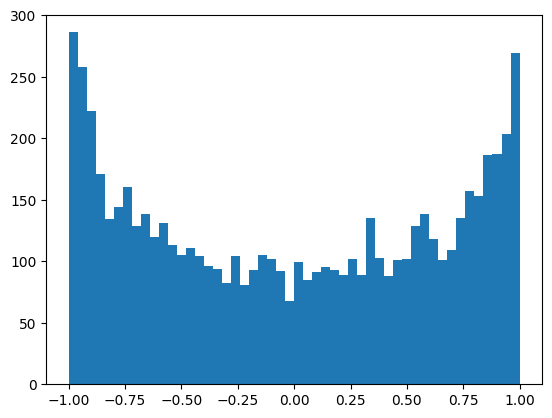

In [34]:
plt.hist(h.view(-1).tolist(), 50)

(array([  1.,   0.,   3.,   4.,   2.,   3.,   8.,  10.,  13.,  16.,  18.,
         39.,  55.,  70.,  95., 123., 158., 184., 177., 218., 273., 319.,
        343., 339., 363., 395., 368., 367., 381., 344., 295., 241., 235.,
        216., 188.,  99., 119.,  73.,  71.,  53.,  31.,  36.,  28.,  11.,
          3.,   7.,   3.,   1.,   0.,   1.]),
 array([-4.33850098, -4.17213701, -4.00577304, -3.83940907, -3.6730451 ,
        -3.50668113, -3.34031716, -3.17395319, -3.00758923, -2.84122526,
        -2.67486129, -2.50849732, -2.34213335, -2.17576938, -2.00940541,
        -1.84304144, -1.67667747, -1.51031351, -1.34394954, -1.17758557,
        -1.0112216 , -0.84485763, -0.67849366, -0.51212969, -0.34576572,
        -0.17940176, -0.01303779,  0.15332618,  0.31969015,  0.48605412,
         0.65241809,  0.81878206,  0.98514603,  1.15151   ,  1.31787396,
         1.48423793,  1.6506019 ,  1.81696587,  1.98332984,  2.14969381,
         2.31605778,  2.48242175,  2.64878572,  2.81514968,  2.98151365,
 

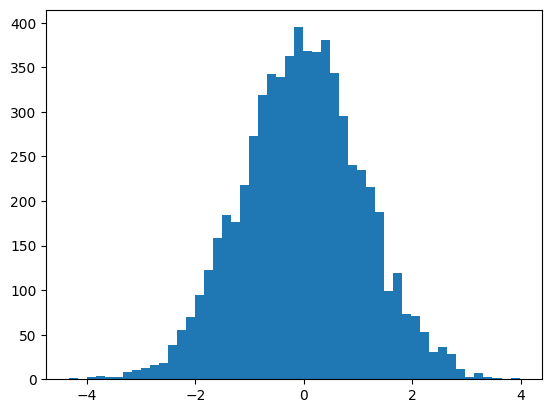

In [35]:
plt.hist(hpreact.view(-1).tolist(), 50)

let's train on the whole dataset

In [36]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * 0.2
b1 = torch.rand(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
print("number of parameters: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

number of parameters:  13374


In [37]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    emb = C[Xb]                             # chars embedded into vectors
    emb_cat = emb.view(emb.shape[0], -1)    # concatenated vectors
    hpreact = emb_cat @ W1 + b1             # hidden layer pre-activation
    h = torch.tanh(hpreact)                 # hidden layer
    logits = h @ W2 + b2                    # output layer
    loss = F.cross_entropy(logits, Y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.5004
  10000/ 300000: 1.6535
  20000/ 300000: 1.9707
  30000/ 300000: 1.7741
  40000/ 300000: 2.1437
  50000/ 300000: 1.7877
  60000/ 300000: 2.1171
  70000/ 300000: 1.9607
  80000/ 300000: 2.1125
  90000/ 300000: 1.6979
 100000/ 300000: 1.9310
 110000/ 300000: 1.8736
 120000/ 300000: 2.1563
 130000/ 300000: 2.1784
 140000/ 300000: 2.4201
 150000/ 300000: 1.7077
 160000/ 300000: 2.3165
 170000/ 300000: 2.4117
 180000/ 300000: 2.2991
 190000/ 300000: 2.2109
 200000/ 300000: 1.6729
 210000/ 300000: 1.9781
 220000/ 300000: 1.5457
 230000/ 300000: 1.5794
 240000/ 300000: 2.2025
 250000/ 300000: 1.7199
 260000/ 300000: 1.6612
 270000/ 300000: 1.7095
 280000/ 300000: 1.9556
 290000/ 300000: 2.1014


In [38]:
split_loss('train')
split_loss('val')

train 1.969064474105835
val 1.9970550537109375


how to choose the magic numbers?

magic numbers are the numbers that help us maintain the ~1 standard deviation  
if the deviation is too small or too large then after a few iterations gradiens vanish or explode

tensor(-0.0001) tensor(1.0015)
tensor(8.6909e-05) tensor(0.9700)


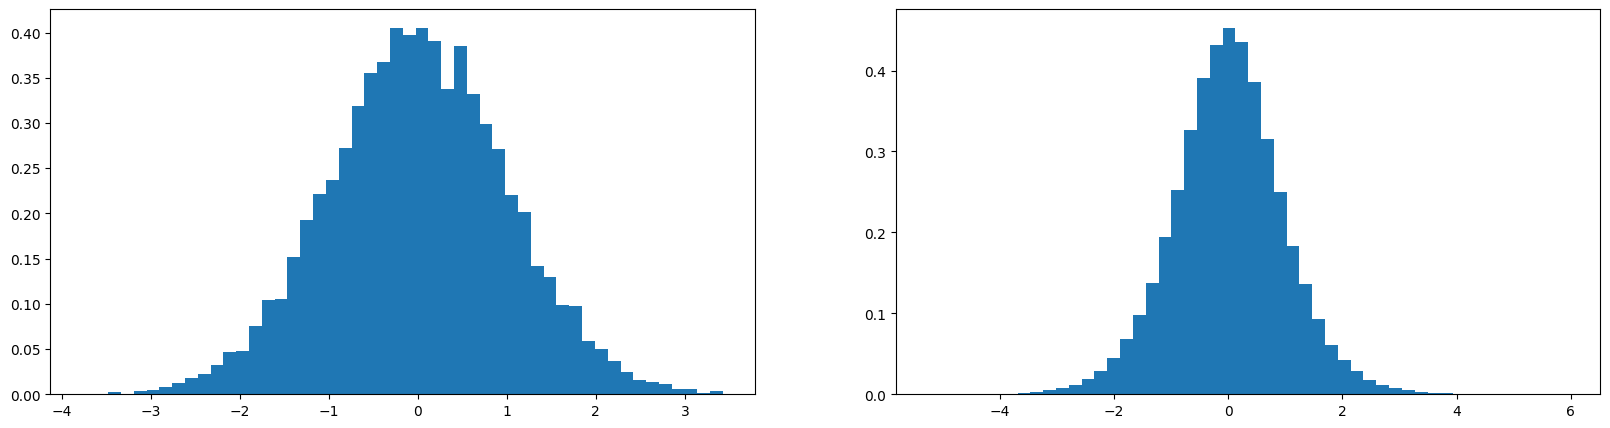

In [39]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5  # the magic number is the square root of input size
y = x @ w

print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

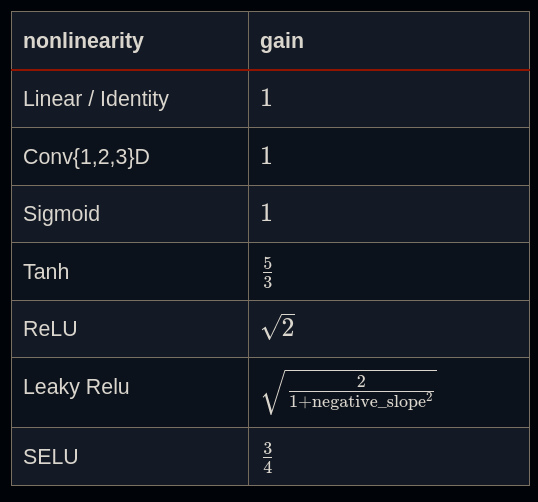  
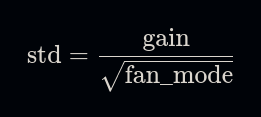  
`torch.nn.init.kaiming_normal_(tensor, a=0, mode='fan_in', nonlinearity='tanh', generator=None)`

In [40]:
(5/3) / (30**0.5)   # n_emb * block_size = 30

0.3042903097250923

In [41]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * (5/3) / ((30)**0.5)
b1 = torch.rand(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
print("number of parameters: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

number of parameters:  13374


In [42]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    emb = C[Xb]                             # chars embedded into vectors
    emb_cat = emb.view(emb.shape[0], -1)    # concatenated vectors
    hpreact = emb_cat @ W1 + b1             # hidden layer pre-activation
    h = torch.tanh(hpreact)                 # hidden layer
    logits = h @ W2 + b2                    # output layer
    loss = F.cross_entropy(logits, Y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.4979
  10000/ 300000: 1.6879
  20000/ 300000: 2.0369
  30000/ 300000: 1.8426
  40000/ 300000: 2.0881
  50000/ 300000: 1.7921
  60000/ 300000: 2.0294
  70000/ 300000: 1.8155
  80000/ 300000: 2.1652
  90000/ 300000: 1.7781
 100000/ 300000: 2.0591
 110000/ 300000: 1.8500
 120000/ 300000: 2.0679
 130000/ 300000: 2.2020
 140000/ 300000: 2.2927
 150000/ 300000: 1.7827
 160000/ 300000: 2.2969
 170000/ 300000: 2.5912
 180000/ 300000: 2.3315
 190000/ 300000: 2.0826
 200000/ 300000: 1.4966
 210000/ 300000: 1.7614
 220000/ 300000: 1.6039
 230000/ 300000: 1.5911
 240000/ 300000: 2.3009
 250000/ 300000: 1.6937
 260000/ 300000: 1.6080
 270000/ 300000: 1.7623
 280000/ 300000: 1.8710
 290000/ 300000: 2.0628


### Batch Norm

settings of previous values aren't that important due to modern innovations like batch norm which are easier to scale

we want hpreact to be ~ gaussian

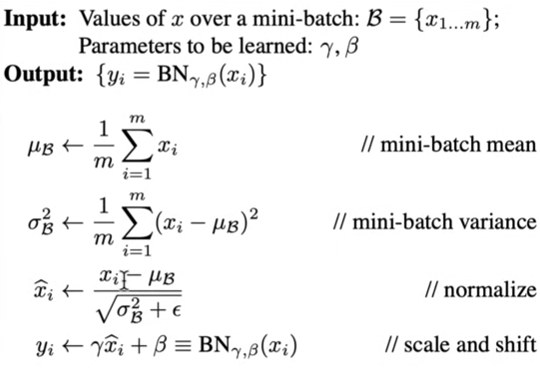

source: https://arxiv.org/pdf/1502.03167

In [64]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * (5/3) / ((30)**0.5)
b1 = torch.rand(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print("number of parameters: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

number of parameters:  13774


In [65]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    emb = C[Xb]                             # chars embedded into vectors
    emb_cat = emb.view(emb.shape[0], -1)    # concatenated vectors
    hpreact = emb_cat @ W1 + b1             # hidden layer pre-activation
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias

    h = torch.tanh(hpreact)                 # hidden layer
    logits = h @ W2 + b2                    # output layer
    loss = F.cross_entropy(logits, Y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.4950
  10000/ 300000: 1.6317
  20000/ 300000: 2.1375
  30000/ 300000: 1.9423
  40000/ 300000: 2.0849
  50000/ 300000: 1.8018
  60000/ 300000: 2.0442
  70000/ 300000: 2.0091
  80000/ 300000: 2.1960
  90000/ 300000: 1.8035
 100000/ 300000: 2.1809
 110000/ 300000: 1.9040
 120000/ 300000: 2.0468
 130000/ 300000: 2.2458
 140000/ 300000: 2.2454
 150000/ 300000: 1.8301
 160000/ 300000: 2.4788
 170000/ 300000: 2.4686
 180000/ 300000: 2.1615
 190000/ 300000: 2.0884
 200000/ 300000: 1.7466
 210000/ 300000: 1.9052
 220000/ 300000: 1.5695
 230000/ 300000: 1.6383
 240000/ 300000: 2.2647
 250000/ 300000: 1.7942
 260000/ 300000: 1.6303
 270000/ 300000: 1.8373
 280000/ 300000: 1.8912
 290000/ 300000: 2.0186


In [66]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, Y_train),
        'val': (X_val, Y_val),
        'test': (X_test, Y_test),
    }[split]

    emb = C[x]      # (N, block_size, n_emb)
    embcat = emb.view(emb.shape[0], -1)    # (N, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9664771556854248
val 1.9818171262741089


with batch norm everything is optimized for the whole batch, so gradients for each example aren't independent, they depend on every example in the batch but it's a feature not a bug. Batch norm acts as a regulizer adding slight fluctuation that prevents the net from overfitting (acting like data augmentation). There is only a problem if you train on small batches (2-8), because there is a lot of noice.

when we deploy the model we want to be able to pass a single example and get a single prediction. but now everything is counted for the whole batch  
after training we want to calculate and reset the batch norm mean and std exactly once over the whole training set

In [67]:
with torch.no_grad():
    emb = C[X_train]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1

    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [68]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, Y_train),
        'val': (X_val, Y_val),
        'test': (X_test, Y_test),
    }[split]

    emb = C[x]      # (N, block_size, n_emb)
    embcat = emb.view(emb.shape[0], -1)    # (N, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9664771556854248
val 1.9818391799926758


we can estimate bnmean and bnstd in a running matter during trainging

In [81]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * (5/3) / ((30)**0.5)
#b1 = torch.rand(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print("number of parameters: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

number of parameters:  13574


In [82]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    emb = C[Xb]                             # chars embedded into vectors
    emb_cat = emb.view(emb.shape[0], -1)    # concatenated vectors

    # linear layer
    hpreact = emb_cat @ W1   # + b1         # b1 is the same for the whole abtch so it doesn't matter after the normalization

    # batch norm layer
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # non-linearity
    h = torch.tanh(hpreact)                 # hidden layer
    logits = h @ W2 + b2                    # output layer
    loss = F.cross_entropy(logits, Y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.5164
  10000/ 300000: 1.4740
  20000/ 300000: 2.5791
  30000/ 300000: 2.4613
  40000/ 300000: 1.9282
  50000/ 300000: 1.9474
  60000/ 300000: 2.0220
  70000/ 300000: 1.8521
  80000/ 300000: 2.2128
  90000/ 300000: 2.3672
 100000/ 300000: 2.0632
 110000/ 300000: 2.3940
 120000/ 300000: 2.1093
 130000/ 300000: 2.2257
 140000/ 300000: 1.6091
 150000/ 300000: 1.8189
 160000/ 300000: 2.1979
 170000/ 300000: 2.2476
 180000/ 300000: 1.9466
 190000/ 300000: 2.3512
 200000/ 300000: 2.2510
 210000/ 300000: 2.2053
 220000/ 300000: 2.0732
 230000/ 300000: 1.3728
 240000/ 300000: 1.7478
 250000/ 300000: 1.7835
 260000/ 300000: 2.0469
 270000/ 300000: 1.9302
 280000/ 300000: 2.4402
 290000/ 300000: 1.8159


(bnmean and bnmean_running) and (bnstd and bnstd_running) are very similar

In [83]:
bnmean[0,:10]

tensor([-1.8567,  1.7272,  0.0138,  1.0010, -1.7521,  0.4018, -0.9167,  1.0570,
         0.1558,  0.5846])

In [84]:
bnmean_running[0,:10]

tensor([-2.0179,  1.1326,  0.2983,  1.0576, -0.9070,  1.0336, -0.4114,  1.0288,
         0.2293, -0.3191])

In [85]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, Y_train),
        'val': (X_val, Y_val),
        'test': (X_test, Y_test),
    }[split]

    emb = C[x]      # (N, block_size, n_emb)
    embcat = emb.view(emb.shape[0], -1)    # (N, block_size * n_emb)
    hpreact = embcat @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9628630876541138
val 1.9770783185958862
